In [92]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt

In [93]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device

device(type='cuda')

In [94]:
#data loading

def get_data_loaders(batch_size = 64):

    transform = transforms.Compose( #pipeline
        [
            transforms.ToTensor(),
            transforms.Normalize((0.5,), (0.5,))    # between -1 & 1
        ]
    )

    train_set = torchvision.datasets.MNIST(root="./data", train=True, transform=transform, download=True)
    test_set = torchvision.datasets.MNIST(root="./data", train=False, transform=transform, download=True)

    train_loader = torch.utils.data.DataLoader(dataset=train_set,batch_size=batch_size, shuffle=True)
    test_loader = torch.utils.data.DataLoader(dataset=test_set, batch_size=batch_size, shuffle=False)

    return train_loader, test_loader


In [95]:
train_loader, test_loader = get_data_loaders()

In [96]:
def visualize_samples(loader, n):
    images, labels = next(iter(loader))
    fig, axes = plt.subplots(1, n, figsize=(10,5))
    for i in range(n):
        axes[i].imshow(images[i].squeeze(), cmap="gray")
        axes[i].set_title(f"label: {labels[i].item()}")
        axes[i].axis("off")

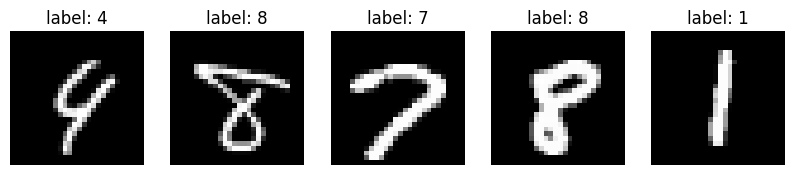

In [97]:
visualize_samples(train_loader, 5)

In [104]:
class NeuralNetwork(nn.Module):

    def __init__(self):
        super(NeuralNetwork, self).__init__()

        #convert 2d img to 1d
        self.flatten = nn.Flatten()

        #first layer
        self.fc1 = nn.Linear(in_features=28*28, out_features=128)

        #activation func
        self.relu = nn.ReLU()

        #second layer
        self.fc2 = nn.Linear(in_features=128, out_features=64)
        
        #output layer
        self.fc3 = nn.Linear(in_features=64, out_features=10)

    def forward(self, x):

        #initial image = 28*28 -> 784
        x = self.flatten(x) #784

        x = self.fc1(x)
        x = self.relu(x)
        x = self.fc2(x)
        x = self.relu(x)
        x = self.fc3(x)

        return x 



In [105]:
model = NeuralNetwork().to(device=device)

In [106]:
def define_loss_and_optimizer(model):
    
    # multi class classification loss function
    criterion = nn.CrossEntropyLoss()
    
    optimizer = optim.Adam(params=model.parameters(), lr=0.001)
    
    return criterion, optimizer

In [107]:
criterion, optimizer = define_loss_and_optimizer(model)

In [108]:
def train_model(model, train_loader, criterion, optimizer, epochs = 10):

    model.train() #train mod 
    train_losses = [] #loss values list after each epoch

    for epoch in range(epochs):
        total_loss = 0

        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)

            optimizer.zero_grad() #set gradieant to zero
            predictions = model(images) #prediction
            loss = criterion(predictions, labels) #calculate loss
            loss.backward() #backward gradiant calculation
            optimizer.step() #update weights

            total_loss = total_loss + loss.item()

        avg_loss = total_loss / len(train_loader)
        train_losses.append(avg_loss)
        print(f"Epoch {epoch+1} / {epochs}, Loss: {avg_loss:.3f}")

    
    plt.figure()
    plt.plot(range(1, len(train_losses) + 1), train_losses, marker='o', linestyle="-", label="Train Loss")
    plt.xlabel('epochs')
    plt.ylabel('loss')
    plt.title('Train Loss')
    plt.legend()
    plt.show()

Epoch 1 / 5, Loss: 0.383
Epoch 2 / 5, Loss: 0.185
Epoch 3 / 5, Loss: 0.136
Epoch 4 / 5, Loss: 0.107
Epoch 5 / 5, Loss: 0.094


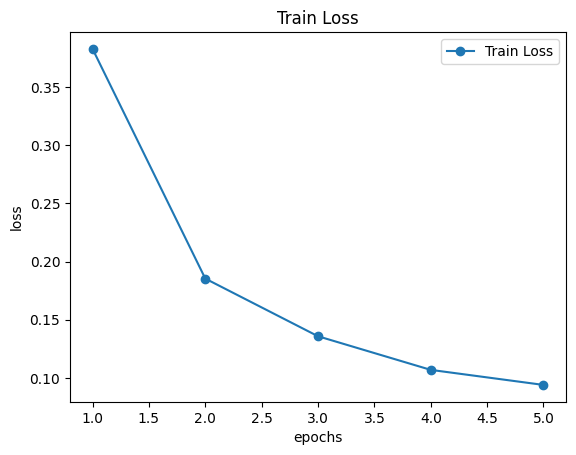

In [109]:
train_model(model, train_loader, criterion, optimizer, epochs=5)

In [112]:
def test_model(model, test_loader):

    model.eval()  # model test mode
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)
            predictions = model(images)
            _, predicted = torch.max(predictions, 1)
            total = total + labels.size(0)
            correct = correct + (predicted == labels).sum().item()

        print(f"Test Accuracy = {100*correct/total:.3f}%")



In [113]:
test_model(model, test_loader)

Test Accuracy = 96.350%


In [114]:
if __name__ == "main":
    train_loader, test_loader = get_data_loaders()
    visualize_samples(train_loader, 5)
    model = NeuralNetwork.to(device)
    criterion, optimizer = define_loss_and_optimizer(model)
    train_model(model, train_loader, criterion, optimizer)
    test_model(model, test_loader)